In [2]:
#Libraries
import os
import shutil #moving and coping files
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras import Model

In [3]:
import kagglehub

path=kagglehub.dataset_download("jessicali9530/celeba-dataset")
print("Dataset download txt",path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset download txt /kaggle/input/celeba-dataset


In [4]:
import os
import shutil #moving and coping files

#create a smaller Dataset (500 Images)
source_folder =os.path.join(path,"img_align_celeba","img_align_celeba")

destination_folder="celeba_small/faces"

os.makedirs(destination_folder,exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder,img),
        os.path.join(destination_folder,img),
    )
print("copid", len(images),"images")

copid 5000 images


In [5]:
#Data prepricessing
IMAGES_SIZE = (128,128)

BATCH_SIZE = 64


In [6]:

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)


In [7]:
#Load Dataset
train_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGES_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training",
)

Found 4000 images belonging to 1 classes.


In [8]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGES_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation",
)

Found 1000 images belonging to 1 classes.


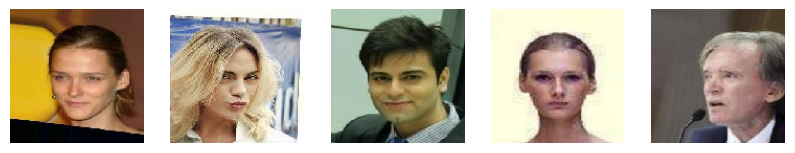

In [9]:
#Display samples images
images, _ = next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [10]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input

#Build convolutional autoencoder
#Encoder
input_img = Input(shape=(128,128,3))
x = Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same",

)(input_img)
x = MaxPooling2D(
    (2,2),
    padding="same",
)(x)
encoder = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same',
)(x)

In [11]:
#Decoder
x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same',

)(encoder)
x = UpSampling2D((2,2))(x)
x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
)(x)
decoder = Conv2D(
    3,
    (3,3),
    activation='sigmoid',
    padding='same',
)(x)

In [12]:
from tensorflow.keras import Model

#create model
autoencoder=Model(
    input_img,
    decoder
)

In [13]:
#compie model
autoencoder.compile(optimizer="adam",loss="binary_crossentropy")

In [14]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#train model
history=autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 310ms/step - loss: 0.5351 - val_loss: 0.4854
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 0.4827 - val_loss: 0.4813
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.4788 - val_loss: 0.4783
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.4775 - val_loss: 0.4766
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - loss: 0.4752 - val_loss: 0.4750
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.4745 - val_loss: 0.4741
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.4740 - val_loss: 0.4736
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.4740 - val_loss: 0.4734
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - loss: 0.4728 - val_loss: 0.4730
Epoch 10/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - loss: 0.4728 - val_loss: 0.4729
Epoch 11/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.4726 - val_loss: 0.4727
Epoch 12/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/ste

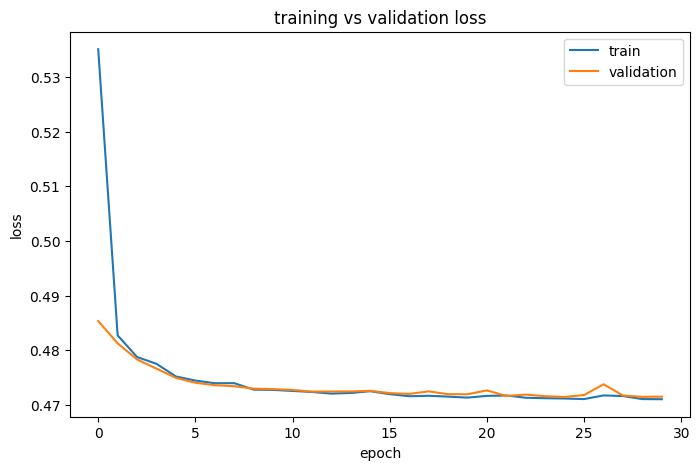

In [16]:
 #plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('training vs validation loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'])
plt.show()

In [17]:
#evaluate model
loss=autoencoder.evaluate(validation_generator)
print("validation loss",loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.4715
validation loss 0.47152087092399597


In [18]:
#reconstruct images
images,_=next(validation_generator)
reconstructed_images=autoencoder.predict(images)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


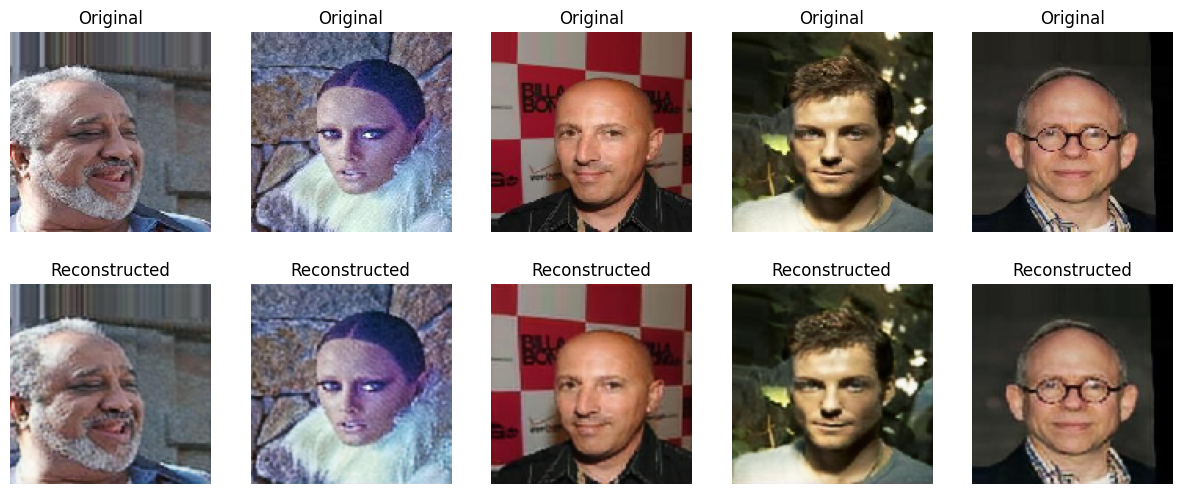

In [19]:
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("Original")
  plt.axis("off")
  plt.subplot(2,n,i+n+1)
  plt.imshow(reconstructed_images[i])
  plt.title("Reconstructed")
  plt.axis("off")
plt.show()